In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
BASE_PATH = "/content/drive/MyDrive/KeepCoding/NLP_SEARCHING/practica_final_nlp"
DATA_PATH = os.path.join(BASE_PATH, "data")

file_path = os.path.join(DATA_PATH, "musical_instruments_reviews_preprocessed.csv")

df_reviews = pd.read_csv(file_path)

df_reviews.head()

,reviewText,overall,summary,sentiment,text,text_clean
0,"Not much to write about here, but it does exac...",5,good,1,"good Not much to write about here, but it does...",good much write exactly supposed filter pop so...
1,The product does exactly as it should and is q...,5,Jake,1,Jake The product does exactly as it should and...,jake product exactly quite affordablei realize...
2,The primary job of this device is to block the...,5,It Does The Job Well,1,It Does The Job Well The primary job of this d...,job well primary job device block breath would...
3,Nice windscreen protects my MXL mic and preven...,5,GOOD WINDSCREEN FOR THE MONEY,1,GOOD WINDSCREEN FOR THE MONEY Nice windscreen ...,good windscreen money nice windscreen protects...
4,This pop filter is great. It looks and perform...,5,No more pops when I record my vocals.,1,No more pops when I record my vocals. This pop...,pop record vocal pop filter great look perform...


In [4]:
X = df_reviews["text_clean"].fillna("")
y = df_reviews["sentiment"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
vectorizer = CountVectorizer(max_features=5000)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)

In [7]:
final_model = LogisticRegression(max_iter=1000)

final_model.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

In [8]:
y_pred = final_model.predict(X_test_bow)

In [9]:
# metricas finales
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo final:", accuracy)


Accuracy del modelo final: 0.8889430102289333


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.39      0.46       248
           1       0.92      0.96      0.94      1805

    accuracy                           0.89      2053
   macro avg       0.74      0.67      0.70      2053
weighted avg       0.88      0.89      0.88      2053



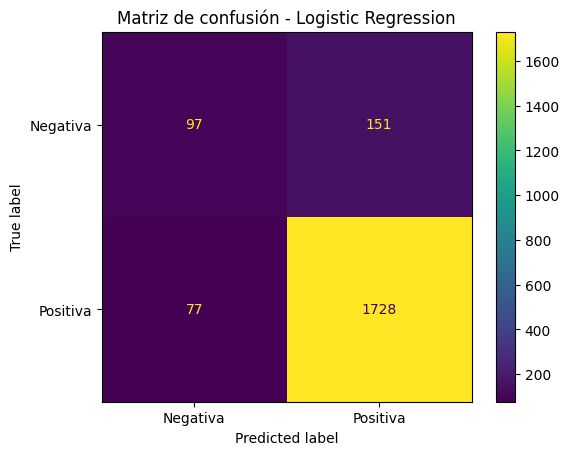

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negativa", "Positiva"]
)

disp.plot()

plt.title("Matriz de confusión - Logistic Regression")
plt.show()

In [12]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.56      0.39      0.46       248
           1       0.92      0.96      0.94      1805

    accuracy                           0.89      2053
   macro avg       0.74      0.67      0.70      2053
weighted avg       0.88      0.89      0.88      2053



El modela clasifica corectamente el 89% de los reviews. Clase positiva (1) precision = 0.92
recall = 0.96
f1-score = 0.94
y es débil para la clase negativa (0) precision = 0.56
recall = 0.39
f1-score = 0.46 es un dataset desbalanceado

# Conclusiones finales

En esta práctica se desarrolló un pipeline completo de NLP para análisis de sentimiento utilizando reviews de productos musicales de Amazon.
También se analizaron palabras frecuentes, n-grams, nubes de palabras y embeddings Word2Vec para comprender mejor la estructura semántica del corpus.
Posteriormente se implementó una etapa de preprocesamiento que incluyó normalización de texto, eliminación de puntuación, stopwords y lematización. Esto permitió reducir ruido y preparar adecuadamente las reviews para el entrenamiento de modelos.
Para el modelado se utilizó un enfoque Bag of Words mediante CountVectorizer y se entrenaron dos modelos clásicos de NLP: Multinomial Naive Bayes y Logistic Regression.
El modelo final seleccionado fue Logistic Regression debido a su mejor desempeño general
El modelo alcanzó un accuracy aproximado del 89%, mostrando excelente desempeño en la detección de reviews positivas.

En general, los resultados demuestran que técnicas clásicas de NLP combinadas con un adecuado preprocesamiento pueden ofrecer resultados satisfactorios en tareas de análisis de sentimiento.